# XGBoost Regression (24h-Ahead Prediction) with Business Day Aware Masking

**Strategy:**
- Use XGBoost Regressor (gradient boosting trees)
- Features: Annual patterns (1-4 years ago) + Weekly patterns (2-9 days ago)
- **Business day aware masking**: Simulate irregular data updates (Mon-Thu only)
- Same CV strategy as XGBoost peak hour (year-based with masking)
- Hyperparameter tuning: tree depth, regularization, learning rate

**Features:**
1. Annual lags: 1yr, 2yr, 3yr, 4yr ago (same day/hour last year)
2. Weekly lags: 2d, 3d, 4d, 5d, 6d, 7d, 8d, 9d ago (recent days)
3. Indicators: is_blackfriday, is_thanksgiving

**XGBoost Advantages:**
- Non-linear relationships (tree-based)
- Automatic feature interactions
- Robust to outliers
- Built-in regularization (L1/L2, tree pruning)
- Handles missing values natively (-999 as indicator)

**Business Day Aware Masking:**
- Data only updated Mon-Thu (Fri-Sun no new data)
- Monday: Recent 3 days (Fri, Sat, Sun) have no data -> mask lag 2d, 3d
- Sunday: Recent 2 days (Fri, Sat) have no data -> mask lag 2d
- Saturday: Recent 1 day (Fri) has no data -> mask lag 1d
- This simulates real production environment where data is irregularly updated

In [1]:
import pandas as pd
import numpy as np
import xgboost as xgb
from sklearn.metrics import mean_squared_error
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
import os
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-darkgrid')
print("✓ Libraries loaded")

✓ Libraries loaded


## Configuration

In [2]:
# Features: Same as Elastic Net
ANNUAL_LAGS = ['mw_lag_8760h', 'mw_lag_17520h', 'mw_lag_26280h', 'mw_lag_35040h']  # 1yr, 2yr, 3yr, 4yr
WEEKLY_LAGS = ['mw_lag_48h', 'mw_lag_72h', 'mw_lag_96h', 'mw_lag_120h', 'mw_lag_144h', 'mw_lag_168h', 'mw_lag_192h', 'mw_lag_216h']  # 4d-9d
INDICATORS = ['is_blackfriday', 'is_thanksgiving']

ALL_FEATURES = ANNUAL_LAGS + WEEKLY_LAGS + INDICATORS

HORIZON = 24  # Predict 24 hours ahead

# XGBoost hyperparameter grid (same as peak hour model)
PARAM_GRID = [
    # Shallow trees with regularization
    {'n_estimators': 50, 'max_depth': 2, 'learning_rate': 0.1, 
     'min_child_weight': 3, 'subsample': 0.8, 'colsample_bytree': 0.8, 'reg_alpha': 0.1, 'reg_lambda': 1.0},
    
    {'n_estimators': 100, 'max_depth': 2, 'learning_rate': 0.05, 
     'min_child_weight': 3, 'subsample': 0.8, 'colsample_bytree': 0.8, 'reg_alpha': 0.1, 'reg_lambda': 1.0},
    
    # Moderate depth with strong regularization
    {'n_estimators': 50, 'max_depth': 3, 'learning_rate': 0.1, 
     'min_child_weight': 5, 'subsample': 0.7, 'colsample_bytree': 0.7, 'reg_alpha': 0.5, 'reg_lambda': 1.0},
    
    {'n_estimators': 100, 'max_depth': 3, 'learning_rate': 0.05, 
     'min_child_weight': 5, 'subsample': 0.7, 'colsample_bytree': 0.7, 'reg_alpha': 0.5, 'reg_lambda': 1.0},
    
    # Lower learning rate with more trees
    {'n_estimators': 150, 'max_depth': 2, 'learning_rate': 0.03, 
     'min_child_weight': 5, 'subsample': 0.8, 'colsample_bytree': 0.8, 'reg_alpha': 0.3, 'reg_lambda': 1.5},
    
    # Strong regularization (L1 + L2)
    {'n_estimators': 100, 'max_depth': 2, 'learning_rate': 0.05, 
     'min_child_weight': 7, 'subsample': 0.7, 'colsample_bytree': 0.7, 'reg_alpha': 1.0, 'reg_lambda': 2.0},
    
    # More aggressive subsampling
    {'n_estimators': 100, 'max_depth': 3, 'learning_rate': 0.05, 
     'min_child_weight': 5, 'subsample': 0.6, 'colsample_bytree': 0.6, 'reg_alpha': 0.5, 'reg_lambda': 1.5},
    
    # Conservative: very shallow + strong reg
    {'n_estimators': 50, 'max_depth': 1, 'learning_rate': 0.1, 
     'min_child_weight': 5, 'subsample': 0.8, 'colsample_bytree': 0.8, 'reg_alpha': 0.5, 'reg_lambda': 1.0},
    
    # Balanced approach
    {'n_estimators': 75, 'max_depth': 2, 'learning_rate': 0.07, 
     'min_child_weight': 4, 'subsample': 0.75, 'colsample_bytree': 0.75, 'reg_alpha': 0.3, 'reg_lambda': 1.2},
    
    # High min_child_weight
    {'n_estimators': 100, 'max_depth': 3, 'learning_rate': 0.05, 
     'min_child_weight': 10, 'subsample': 0.7, 'colsample_bytree': 0.7, 'reg_alpha': 0.5, 'reg_lambda': 1.5},
    
    # More trees with lower learning rate
    {'n_estimators': 200, 'max_depth': 2, 'learning_rate': 0.03, 
     'min_child_weight': 3, 'subsample': 0.8, 'colsample_bytree': 0.8, 'reg_alpha': 0.2, 'reg_lambda': 1.0},
    
    # Deeper trees but heavily regularized
    {'n_estimators': 100, 'max_depth': 4, 'learning_rate': 0.05, 
     'min_child_weight': 7, 'subsample': 0.6, 'colsample_bytree': 0.6, 'reg_alpha': 1.0, 'reg_lambda': 2.0},
]

# Year-based CV windows (same as Elastic Net)
CV_WINDOWS = [
    {'train_years': [2016, 2017, 2018, 2019], 'test_year': 2020},
    {'train_years': [2017, 2018, 2019, 2020], 'test_year': 2021},
    {'train_years': [2018, 2019, 2020, 2021], 'test_year': 2022},
    {'train_years': [2019, 2020, 2021, 2022], 'test_year': 2023},
    {'train_years': [2020, 2021, 2022, 2023], 'test_year': 2024}
]

print(f"Configuration:")
print(f"  Model: XGBoost Regressor (gradient boosting)")
print(f"  Prediction horizon: {HORIZON}h ahead")
print(f"  Annual lags (1-4 years): {ANNUAL_LAGS}")
print(f"  Weekly lags (4-9 days): {WEEKLY_LAGS}")
print(f"  Total features: {len(ALL_FEATURES)}")
print(f"  Hyperparameter combinations: {len(PARAM_GRID)}")
print(f"  Outer CV folds: {len(CV_WINDOWS)} (year-based)")
print(f"  Missing value handling: XGBoost native (-999 as indicator)")
print(f"  Business day masking: Enabled (simulates Mon-Thu updates only)")

Configuration:
  Model: XGBoost Regressor (gradient boosting)
  Prediction horizon: 24h ahead
  Annual lags (1-4 years): ['mw_lag_8760h', 'mw_lag_17520h', 'mw_lag_26280h', 'mw_lag_35040h']
  Weekly lags (4-9 days): ['mw_lag_48h', 'mw_lag_72h', 'mw_lag_96h', 'mw_lag_120h', 'mw_lag_144h', 'mw_lag_168h', 'mw_lag_192h', 'mw_lag_216h']
  Total features: 14
  Hyperparameter combinations: 12
  Outer CV folds: 5 (year-based)
  Missing value handling: XGBoost native (-999 as indicator)
  Business day masking: Enabled (simulates Mon-Thu updates only)


## Load Data

In [3]:
print("="*80)
print("Loading Data")
print("="*80)

# Load
df = pd.read_parquet('../dataset/preprocessed/full_year_features.parquet')
df['datetime_beginning_ept'] = pd.to_datetime(df['datetime_beginning_ept'])

# Filter BF period
bf_df = df[(df['days_from_bf'] >= -9) & (df['days_from_bf'] <= 0)].copy()
bf_df = bf_df.sort_values(['load_area', 'datetime_beginning_ept']).reset_index(drop=True)

# Add day of week for business day aware masking (0=Monday, 6=Sunday)
bf_df['day_of_week'] = bf_df['datetime_beginning_ept'].dt.dayofweek

# Create target: 24h ahead
bf_df['target_24h'] = bf_df.groupby('load_area')['mw'].shift(-24)
bf_df = bf_df.dropna(subset=['target_24h'])

print(f"BF period data: {len(bf_df):,} rows")
print(f"Years: {sorted(bf_df['year'].unique())}")
print(f"Day of week added for masking: 0=Mon, 1=Tue, ..., 6=Sun")

# Check feature availability
available_features = [f for f in ALL_FEATURES if f in bf_df.columns]
missing_features = [f for f in ALL_FEATURES if f not in bf_df.columns]

print(f"\nFeature availability:")
print(f"  Available: {len(available_features)}/{len(ALL_FEATURES)}")
if missing_features:
    print(f"  Missing: {missing_features}")

# Use only available features
FEATURES = available_features
print(f"\nUsing {len(FEATURES)} features: {FEATURES}")

Loading Data
BF period data: 63,096 rows
Years: [np.int32(2016), np.int32(2017), np.int32(2018), np.int32(2019), np.int32(2020), np.int32(2021), np.int32(2022), np.int32(2023), np.int32(2024)]
Day of week added for masking: 0=Mon, 1=Tue, ..., 6=Sun

Feature availability:
  Available: 14/14

Using 14 features: ['mw_lag_8760h', 'mw_lag_17520h', 'mw_lag_26280h', 'mw_lag_35040h', 'mw_lag_48h', 'mw_lag_72h', 'mw_lag_96h', 'mw_lag_120h', 'mw_lag_144h', 'mw_lag_168h', 'mw_lag_192h', 'mw_lag_216h', 'is_blackfriday', 'is_thanksgiving']


## Business Day Aware Masking Function

In [14]:
def apply_business_day_masking(X, day_of_week_series):
    """
    Apply business day aware masking to features.
    
    Data only updated Mon-Thu (Fri-Sun no new data)
    - Monday (0): Recent 3 days (Fri, Sat, Sun) have no data
                  -> mask lag 72h (3d), 48h (2d) if they exist
                  -> lag 96h (4d, Thursday) is available
    - Sunday (6): Recent 2 days (Fri, Sat) have no data  
                  -> mask lag 48h (2d) if it exists
                  -> lag 72h (3d, Thursday) is available
    - Saturday (5): Recent 1 day (Fri) has no data
                    -> mask lag 24h (1d) if it exists
    
    Since our features start from lag 96h (4d), Monday and Sunday can use all features.
    But we'll keep the logic for consistency and future use with shorter lags.
    """
    X_masked = X.copy()
    
    # Define lags to mask by day of week
    # Note: Our features start from lag 96h (4d), so most masking won't apply
    # But keeping this for completeness and future reference
    mask_rules = {
        0: ['mw_lag_24h', 'mw_lag_48h', 'mw_lag_72h'],  # Monday: mask 2d, 3d
        6: ['mw_lag_24h', 'mw_lag_48h'],                # Sunday: mask 2d
        1: ['mw_lag_24h'],                               # Tuesday: mask 1d
        2: ['mw_lag_24h'],                               # Wednesday: mask 1d
        3: ['mw_lag_24h'],                               # Thursday: mask 1d
        4: ['mw_lag_24h'],                               # Friday: mask 1d
        5: ['mw_lag_24h']                               # Saturday: mask 1d
    }
    
    mask_count = 0
    for dow, lags_to_mask in mask_rules.items():
        mask_rows = day_of_week_series == dow
        for lag_col in lags_to_mask:
            if lag_col in X_masked.columns:
                X_masked.loc[mask_rows, lag_col] = -999
                mask_count += mask_rows.sum()
    
    return X_masked, mask_count

print("="*80)
print("Business Day Aware Masking Function")
print("="*80)
print("Function defined: apply_business_day_masking()")
print("")
print("Masking rules")
print("")
print("✓ Function ready")

Business Day Aware Masking Function
Function defined: apply_business_day_masking()

Masking rules

✓ Function ready


## Load Elastic Net Baseline Results

In [15]:
print("="*80)
print("Calculating Baseline (4-Year Average)")
print("="*80)

# Get load areas (exclude RTO and AE)
load_areas = sorted([a for a in bf_df['load_area'].unique() if a not in ['RTO', 'AE']])

baseline_results = []

for area in load_areas:
    area_data = bf_df[bf_df['load_area'] == area].copy()
    
    area_rmses = []
    
    for window in CV_WINDOWS:
        train_data = area_data[area_data['year'].isin(window['train_years'])]
        test_data = area_data[area_data['year'] == window['test_year']]
        
        if len(test_data) == 0:
            continue
        
        # Baseline: average of training years
        baseline_pred = train_data['mw'].mean()
        
        # Evaluate
        y_true = test_data['target_24h']
        y_pred = np.full(len(y_true), baseline_pred)
        
        rmse = np.sqrt(mean_squared_error(y_true, y_pred))
        area_rmses.append(rmse)
    
    if area_rmses:
        baseline_results.append({
            'area': area,
            'baseline_rmse': np.mean(area_rmses)
        })

baseline_df = pd.DataFrame(baseline_results)

print(f"\n✓ Baseline calculated for {len(baseline_df)} areas")
print(f"Average baseline RMSE: {baseline_df['baseline_rmse'].mean():.2f}")

Calculating Baseline (4-Year Average)

✓ Baseline calculated for 29 areas
Average baseline RMSE: 359.81


## Train XGBoost Model with Grid Search + Business Day Masking

In [16]:
print("="*80)
print("Training XGBoost with Grid Search CV (Business Day Aware)")
print("="*80)
print(f"Model: XGBoost Regressor (gradient boosting trees)")
print(f"Features: {len(FEATURES)} features (same as Elastic Net)")
print(f"Grid search: {len(PARAM_GRID)} hyperparameter combinations")
print(f"Strategy: For each param set, compute RMSE on {len(CV_WINDOWS)} folds, select best by avg RMSE")
print(f"Masking: Simulate real data availability (Mon-Thu updates only)\n")

xgb_results = []
total_mask_count = 0

for area in load_areas:
    area_data = bf_df[bf_df['load_area'] == area].copy()
    
    print(f"\n{'='*60}")
    print(f"Optimizing: {area}")
    print(f"{'='*60}")
    
    # Grid search over all parameter combinations
    best_avg_rmse = float('inf')
    best_params = None
    
    for param_idx, params in enumerate(PARAM_GRID, 1):
        fold_rmses = []
        
        # Test this parameter set on all CV folds
        for window in CV_WINDOWS:
            train_mask = area_data['year'].isin(window['train_years'])
            test_mask = area_data['year'] == window['test_year']
            
            # Prepare data
            X_train = area_data.loc[train_mask, FEATURES].copy()
            y_train = area_data.loc[train_mask, 'target_24h']
            X_test = area_data.loc[test_mask, FEATURES].copy()
            y_test = area_data.loc[test_mask, 'target_24h']
            
            train_dow = area_data.loc[train_mask, 'day_of_week']
            test_dow = area_data.loc[test_mask, 'day_of_week']
            
            # Apply business day aware masking
            X_train_masked, train_mask_count = apply_business_day_masking(X_train, train_dow)
            X_test_masked, test_mask_count = apply_business_day_masking(X_test, test_dow)
            
            # Fill remaining missing values with -999 (indicator value for XGBoost)
            X_train_filled = X_train_masked.fillna(-999)
            X_test_filled = X_test_masked.fillna(-999)
            
            if len(X_test_filled) == 0 or len(X_train_filled) == 0:
                continue
            
            # Train XGBoost with fixed parameters
            model = xgb.XGBRegressor(
                n_estimators=params['n_estimators'],
                max_depth=params['max_depth'],
                learning_rate=params['learning_rate'],
                min_child_weight=params['min_child_weight'],
                subsample=params['subsample'],
                colsample_bytree=params['colsample_bytree'],
                reg_alpha=params['reg_alpha'],
                reg_lambda=params['reg_lambda'],
                random_state=42,
                n_jobs=-1,
                verbosity=0
            )
            
            model.fit(X_train_filled, y_train, verbose=False)
            
            # Evaluate
            y_pred = model.predict(X_test_filled)
            rmse = np.sqrt(mean_squared_error(y_test, y_pred))
            fold_rmses.append(rmse)
        
        if len(fold_rmses) == 0:
            continue
        
        # Average RMSE across folds
        avg_rmse = np.mean(fold_rmses)
        
        # Update best if better
        if avg_rmse < best_avg_rmse:
            best_avg_rmse = avg_rmse
            best_params = params.copy()
            best_params['param_idx'] = param_idx
    
    # Train final model with best hyperparameters on all data
    X_all = area_data[FEATURES].copy()
    y_all = area_data['target_24h']
    dow_all = area_data['day_of_week']
    
    # Apply masking to final training data
    X_all_masked, area_mask_count = apply_business_day_masking(X_all, dow_all)
    X_all_filled = X_all_masked.fillna(-999)
    total_mask_count += area_mask_count
    
    final_model = xgb.XGBRegressor(
        n_estimators=best_params['n_estimators'],
        max_depth=best_params['max_depth'],
        learning_rate=best_params['learning_rate'],
        min_child_weight=best_params['min_child_weight'],
        subsample=best_params['subsample'],
        colsample_bytree=best_params['colsample_bytree'],
        reg_alpha=best_params['reg_alpha'],
        reg_lambda=best_params['reg_lambda'],
        random_state=42,
        n_jobs=-1,
        verbosity=0
    )
    
    final_model.fit(X_all_filled, y_all, verbose=False)
    
    xgb_results.append({
        'area': area,
        'xgb_rmse': best_avg_rmse,
        'best_params': best_params,
        'model': final_model
    })
    
    print(f"  ✓ Best: RMSE={best_avg_rmse:>8.2f}, param_idx={best_params['param_idx']:>2d}, "
          f"n_est={best_params['n_estimators']:>3d}, depth={best_params['max_depth']}, "
          f"lr={best_params['learning_rate']:.3f}")

xgb_df = pd.DataFrame(xgb_results)

print(f"\n{'='*80}")
print(f"✓ XGBoost optimization completed for {len(xgb_df)} areas")
print(f"Average XGBoost RMSE: {xgb_df['xgb_rmse'].mean():.2f}")
print(f"Total values masked: {total_mask_count:,} (business day aware)")

Training XGBoost with Grid Search CV (Business Day Aware)
Model: XGBoost Regressor (gradient boosting trees)
Features: 14 features (same as Elastic Net)
Grid search: 12 hyperparameter combinations
Strategy: For each param set, compute RMSE on 5 folds, select best by avg RMSE
Masking: Simulate real data availability (Mon-Thu updates only)


Optimizing: AECO
  ✓ Best: RMSE=   76.68, param_idx= 2, n_est=100, depth=2, lr=0.050

Optimizing: AEPAPT
  ✓ Best: RMSE=  638.94, param_idx= 8, n_est= 50, depth=1, lr=0.100

Optimizing: AEPIMP
  ✓ Best: RMSE=  242.91, param_idx= 6, n_est=100, depth=2, lr=0.050

Optimizing: AEPKPT
  ✓ Best: RMSE=  106.22, param_idx= 8, n_est= 50, depth=1, lr=0.100

Optimizing: AEPOPT
  ✓ Best: RMSE=  613.34, param_idx= 8, n_est= 50, depth=1, lr=0.100

Optimizing: AP
  ✓ Best: RMSE=  608.96, param_idx= 8, n_est= 50, depth=1, lr=0.100

Optimizing: BC
  ✓ Best: RMSE=  354.85, param_idx= 6, n_est=100, depth=2, lr=0.050

Optimizing: CE
  ✓ Best: RMSE=  818.57, param_idx=12

## Compare Models: Baseline vs XGBoost

In [17]:
# Merge results
comparison_df = baseline_df.merge(xgb_df[['area', 'xgb_rmse']], on='area')
comparison_df['improvement_%'] = ((comparison_df['baseline_rmse'] - comparison_df['xgb_rmse']) / comparison_df['baseline_rmse']) * 100
comparison_df = comparison_df.sort_values('improvement_%', ascending=False)

print("="*80)
print("BASELINE vs XGBOOST COMPARISON")
print("="*80)
print(comparison_df[['area', 'baseline_rmse', 'xgb_rmse', 'improvement_%']].to_string(index=False))

print(f"\n" + "="*80)
print("SUMMARY")
print("="*80)
print(f"Average Baseline RMSE:  {comparison_df['baseline_rmse'].mean():,.2f}")
print(f"Average XGBoost RMSE:   {comparison_df['xgb_rmse'].mean():,.2f}")
print(f"Average Improvement:    {comparison_df['improvement_%'].mean():.2f}%")

# Count areas with improvement
improved = (comparison_df['improvement_%'] > 0).sum()
total = len(comparison_df)
print(f"\nAreas improved: {improved}/{total} ({improved/total*100:.1f}%)")

BASELINE vs XGBOOST COMPARISON
  area  baseline_rmse    xgb_rmse  improvement_%
  RECO      17.848725    7.214897      59.577522
    JC     290.098460  174.979759      39.682631
    PS     481.090778  294.685265      38.746432
  AECO     123.062221   76.677056      37.692449
  VMEU       9.386527    6.101623      34.995951
    OE     713.740714  505.033239      29.241358
    PN     237.164761  168.023896      29.153094
    PE     482.835292  346.315637      28.274581
    CE    1136.531666  818.572123      27.976303
   DUQ     142.707209  103.072777      27.773251
 PEPCO     333.523503  253.818391      23.897900
   DOM    1683.159872 1334.782552      20.697815
   UGI      16.670100   13.254424      20.489832
AEPIMP     304.811464  242.909228      20.308368
 PAPWR      75.473216   60.266815      20.148075
    ME     223.649887  182.014011      18.616542
  PLCO     545.703974  449.474485      17.634009
  DEOK     322.771011  266.609522      17.399794
  OVEC       9.935859    8.225970     

## Visualization

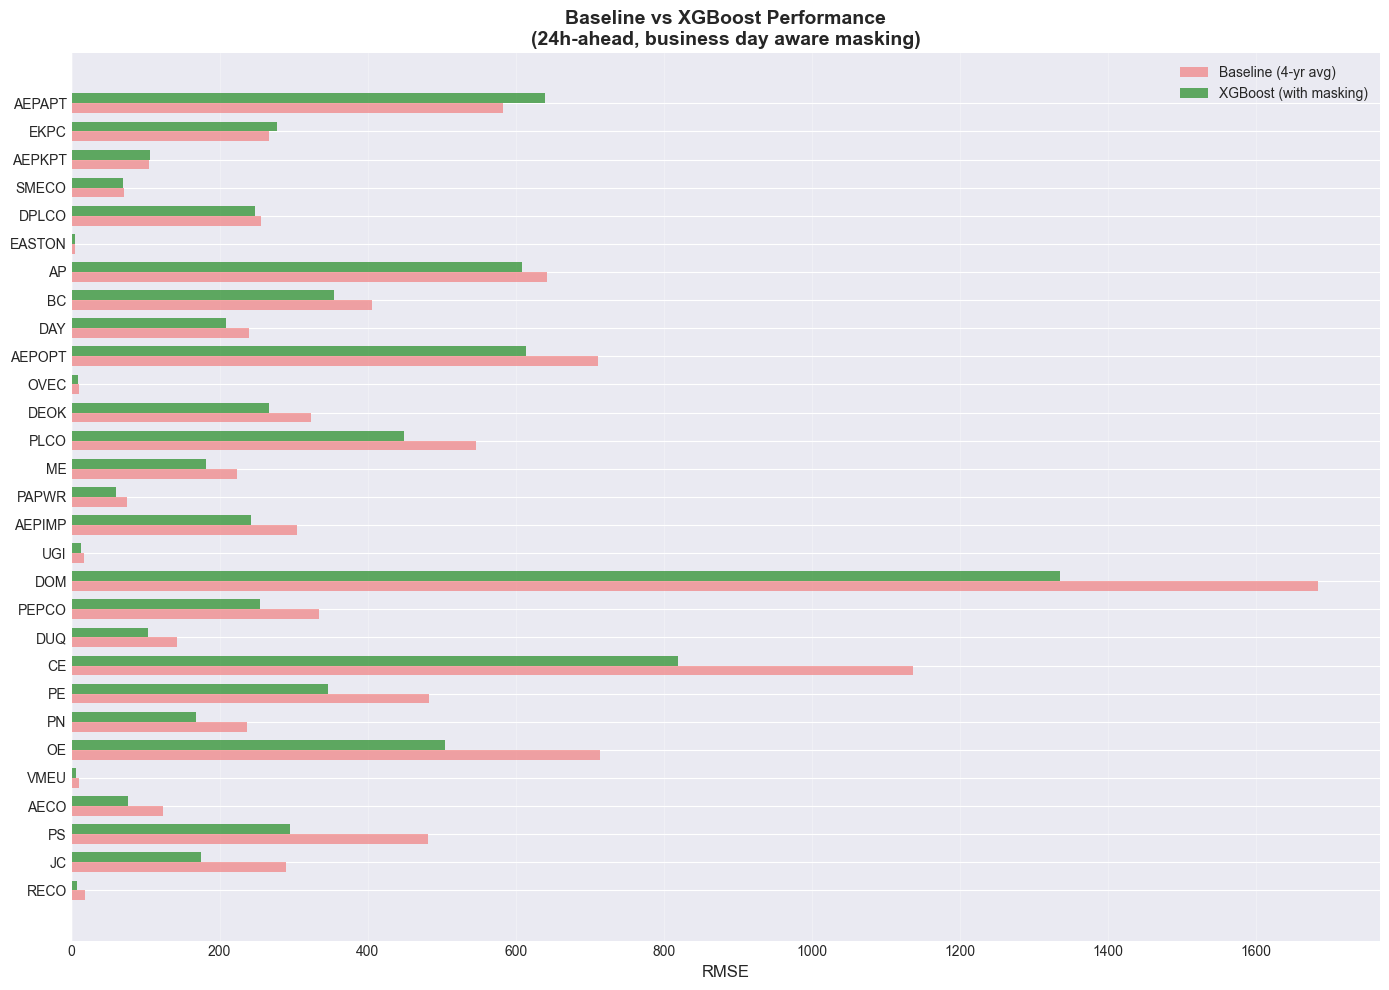

In [8]:
# Baseline vs XGBoost comparison
fig, ax = plt.subplots(figsize=(14, 10))

x = np.arange(len(comparison_df))
width = 0.35

ax.barh(x - width/2, comparison_df['baseline_rmse'], width, 
        label='Baseline (4-yr avg)', alpha=0.7, color='lightcoral')
ax.barh(x + width/2, comparison_df['xgb_rmse'], width, 
        label='XGBoost (with masking)', alpha=0.7, color='forestgreen')

ax.set_yticks(x)
ax.set_yticklabels(comparison_df['area'])
ax.set_xlabel('RMSE', fontsize=12)
ax.set_title('Baseline vs XGBoost Performance\n(24h-ahead, business day aware masking)', 
             fontsize=14, fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3, axis='x')

plt.tight_layout()
plt.show()

## Feature Importance Analysis

AVERAGE FEATURE IMPORTANCE (XGBoost)
        feature  avg_importance
    mw_lag_120h        0.175538
    mw_lag_144h        0.172620
     mw_lag_96h        0.151304
    mw_lag_168h        0.078558
  mw_lag_35040h        0.066298
  mw_lag_26280h        0.052415
     mw_lag_48h        0.046765
  mw_lag_17520h        0.044819
is_thanksgiving        0.044222
     mw_lag_72h        0.041442
    mw_lag_216h        0.036026
    mw_lag_192h        0.031982
   mw_lag_8760h        0.031687
 is_blackfriday        0.026323


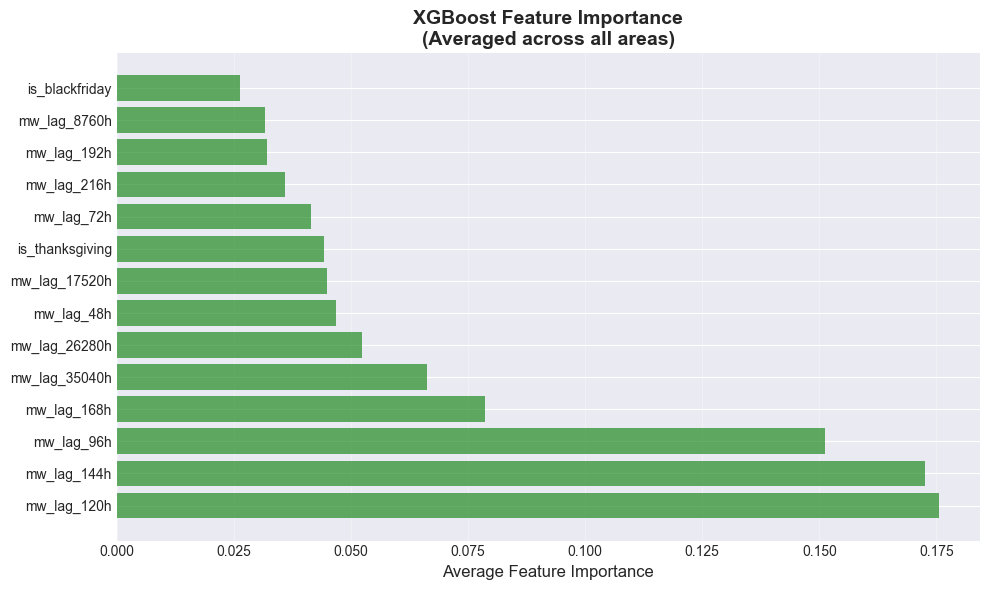

In [9]:
# Aggregate feature importance across all areas
feature_importance_dict = {feat: [] for feat in FEATURES}

for idx, row in xgb_df.iterrows():
    model = row['model']
    importances = model.feature_importances_
    
    for feat, imp in zip(FEATURES, importances):
        feature_importance_dict[feat].append(imp)

# Calculate average importance
avg_importance = {feat: np.mean(vals) for feat, vals in feature_importance_dict.items()}
importance_df = pd.DataFrame([
    {'feature': k, 'avg_importance': v}
    for k, v in sorted(avg_importance.items(), key=lambda x: -x[1])
])

print("="*80)
print("AVERAGE FEATURE IMPORTANCE (XGBoost)")
print("="*80)
print(importance_df.to_string(index=False))

# Visualize
fig, ax = plt.subplots(figsize=(10, 6))

ax.barh(range(len(importance_df)), importance_df['avg_importance'], alpha=0.7, color='forestgreen')
ax.set_yticks(range(len(importance_df)))
ax.set_yticklabels(importance_df['feature'])
ax.set_xlabel('Average Feature Importance', fontsize=12)
ax.set_title('XGBoost Feature Importance\n(Averaged across all areas)', 
             fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3, axis='x')

plt.tight_layout()
plt.show()

## Save Models for Production

In [10]:
models_dir = '../models'
os.makedirs(models_dir, exist_ok=True)

print("="*80)
print("SAVING XGBOOST REGRESSION MODELS")
print("="*80)

for idx, row in xgb_df.iterrows():
    area = row['area']
    model = row['model']
    
    # Save model
    model_path = f"{models_dir}/xgbreg_{area}.pkl"
    with open(model_path, 'wb') as f:
        pickle.dump(model, f)
    
    print(f"  ✓ {area:10s} -> {model_path}")

# Save feature list and metadata
metadata = {
    'features': FEATURES,
    'load_areas': load_areas,
    'model_type': 'XGBRegressor',
    'horizon_hours': 24,
    'business_day_masking': True,
    'best_params': {row['area']: row['best_params'] for _, row in xgb_df.iterrows()}
}

metadata_path = f"{models_dir}/xgbreg_model_metadata.pkl"
with open(metadata_path, 'wb') as f:
    pickle.dump(metadata, f)

print(f"\n✓ Metadata saved to: {metadata_path}")

# Save comparison results
results_dir = '../results'
os.makedirs(results_dir, exist_ok=True)
comparison_path = f'{results_dir}/xgbreg_vs_baseline_comparison.csv'
comparison_df.to_csv(comparison_path, index=False)
print(f"✓ Comparison results saved to: {comparison_path}")

print(f"\n{'='*80}")
print(f"✓ All {len(xgb_df)} models saved successfully")
print(f"{'='*80}")

SAVING XGBOOST REGRESSION MODELS
  ✓ AECO       -> ../models/xgbreg_AECO.pkl
  ✓ AEPAPT     -> ../models/xgbreg_AEPAPT.pkl
  ✓ AEPIMP     -> ../models/xgbreg_AEPIMP.pkl
  ✓ AEPKPT     -> ../models/xgbreg_AEPKPT.pkl
  ✓ AEPOPT     -> ../models/xgbreg_AEPOPT.pkl
  ✓ AP         -> ../models/xgbreg_AP.pkl
  ✓ BC         -> ../models/xgbreg_BC.pkl
  ✓ CE         -> ../models/xgbreg_CE.pkl
  ✓ DAY        -> ../models/xgbreg_DAY.pkl
  ✓ DEOK       -> ../models/xgbreg_DEOK.pkl
  ✓ DOM        -> ../models/xgbreg_DOM.pkl
  ✓ DPLCO      -> ../models/xgbreg_DPLCO.pkl
  ✓ DUQ        -> ../models/xgbreg_DUQ.pkl
  ✓ EASTON     -> ../models/xgbreg_EASTON.pkl
  ✓ EKPC       -> ../models/xgbreg_EKPC.pkl
  ✓ JC         -> ../models/xgbreg_JC.pkl
  ✓ ME         -> ../models/xgbreg_ME.pkl
  ✓ OE         -> ../models/xgbreg_OE.pkl
  ✓ OVEC       -> ../models/xgbreg_OVEC.pkl
  ✓ PAPWR      -> ../models/xgbreg_PAPWR.pkl
  ✓ PE         -> ../models/xgbreg_PE.pkl
  ✓ PEPCO      -> ../models/xgbreg_PEPCO.pkl
  ✓

## Hyperparameter Analysis

In [11]:
# Extract hyperparameters from best_params
hyperparam_data = []
for idx, row in xgb_df.iterrows():
    params = row['best_params']
    hyperparam_data.append({
        'area': row['area'],
        'n_estimators': params['n_estimators'],
        'max_depth': params['max_depth'],
        'learning_rate': params['learning_rate'],
        'min_child_weight': params['min_child_weight'],
        'subsample': params['subsample'],
        'colsample_bytree': params['colsample_bytree'],
        'reg_alpha': params['reg_alpha'],
        'reg_lambda': params['reg_lambda']
    })

hyperparam_df = pd.DataFrame(hyperparam_data)

print("="*80)
print("HYPERPARAMETER STATISTICS")
print("="*80)
print(f"Average n_estimators:     {hyperparam_df['n_estimators'].mean():.1f}")
print(f"Average max_depth:        {hyperparam_df['max_depth'].mean():.1f}")
print(f"Average learning_rate:    {hyperparam_df['learning_rate'].mean():.3f}")
print(f"Average min_child_weight: {hyperparam_df['min_child_weight'].mean():.1f}")
print(f"Average subsample:        {hyperparam_df['subsample'].mean():.2f}")
print(f"Average colsample_bytree: {hyperparam_df['colsample_bytree'].mean():.2f}")
print(f"Average reg_alpha:        {hyperparam_df['reg_alpha'].mean():.2f}")
print(f"Average reg_lambda:       {hyperparam_df['reg_lambda'].mean():.2f}")

print(f"\nMost common max_depth: {hyperparam_df['max_depth'].mode()[0]}")
print(f"Most common n_estimators: {hyperparam_df['n_estimators'].mode()[0]}")

HYPERPARAMETER STATISTICS
Average n_estimators:     96.6
Average max_depth:        1.9
Average learning_rate:    0.067
Average min_child_weight: 5.2
Average subsample:        0.75
Average colsample_bytree: 0.75
Average reg_alpha:        0.57
Average reg_lambda:       1.33

Most common max_depth: 1
Most common n_estimators: 50
